In [2]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

## 30. Euler Angle Kinematics

In [3]:
def rotation_x(phi: float) -> NDArray:
    return np.array(
        [[1, 0, 0], [0, np.cos(phi), np.sin(phi)], [0, -np.sin(phi), np.cos(phi)]]
    )

In [4]:
def rotation_y(theta: float) -> NDArray:
    return np.array(
        [
            [np.cos(theta), 0, -np.sin(theta)],
            [0, 1, 0],
            [np.sin(theta), 0, np.cos(theta)],
        ]
    )

In [5]:
def rotation_z(psi: float) -> NDArray:
    return np.array(
        [[np.cos(psi), np.sin(psi), 0], [-np.sin(psi), np.cos(psi), 0], [0, 0, 1]]
    )

In [6]:
def rotation_xyz(attitude_xyz: NDArray) -> NDArray:
    r_x = rotation_x(attitude_xyz[0])
    r_y = rotation_y(attitude_xyz[1])
    r_z = rotation_z(attitude_xyz[2])
    r = np.matmul(r_x, np.matmul(r_y, r_z))

    return r

In [12]:
def euler_angle_rates_xyz(attitude: NDArray, omega_body: NDArray) -> NDArray:
    phi = attitude[0]
    theta = attitude[1]
    # psi = attitude[2]

    E = np.array(
        [
            [1, np.tan(theta) * np.sin(phi), np.tan(theta) * np.cos(phi)],
            [0, np.cos(phi), -np.sin(phi)],
            [0, np.sin(phi) / np.cos(theta), np.cos(phi) / np.cos(theta)],
        ]
    )

    return np.matmul(E, omega_body)

In [8]:
def euler_integration(x: NDArray, x_dot: NDArray, dt: float) -> NDArray:
    return x + x_dot * dt

In [20]:
attitude = np.deg2rad([0.000001, 0, 0])
omega_body = np.deg2rad([0, 20, 0])
dt = 0.01
time = []
phi = []
theta = []
psi = []

In [21]:
for t in np.arange(0, 20, dt):
    attitude_dot = euler_angle_rates_xyz(attitude, omega_body)
    attitude = euler_integration(attitude, attitude_dot, dt)

    time.append(t)
    phi.append(np.rad2deg(attitude[0]))
    theta.append(np.rad2deg(attitude[1]))
    psi.append(np.rad2deg(attitude[2]))

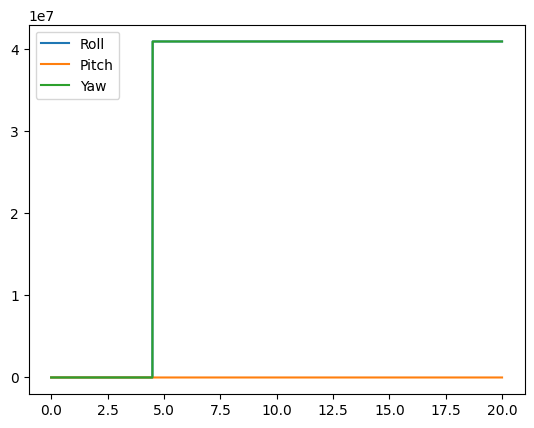

In [22]:
plt.plot(time, phi, label="Roll")
plt.plot(time, theta, label="Pitch")
plt.plot(time, psi, label="Yaw")
plt.legend()
plt.savefig("Attitude.png")